In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

from cariaco_ssm_setup import (
    model, generate_size_classes,
    compute_K_s, compute_mu_max_maranon, compute_I_max,
    compute_fish_kernel_vdl_joint,
)
from resize_cariaco_setup import make_resized_setup, build_cariaco_regenerators
from spectrum_plot import plot_normalised_biomass_spectrum
from xso.parscans import StabilityAnalysisHook

In [2]:
loaded_setup = xr.open_dataset('../parameter_scan/best_cell_stability.nc')

# Use whatever size grid was actually saved
phyto_esd = loaded_setup['Phytoplankton__phyto_esd_index'].values
zoo_esd   = loaded_setup['Zooplankton__zoo_esd_index'].values

with model:
    out = loaded_setup.xsimlab.run(hooks=[StabilityAnalysisHook()])

ss_phyto = out.Phytoplankton__biomass.isel(time=-1).values
ss_zoo   = out.Zooplankton__biomass.isel(time=-1).values
ss_nut   = float(out.Nutrient__value.isel(time=-1).values)

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[INFO] Initial state dimension: 26
[INFO] Initial state: [1.83352691e+00 1.60011862e-01 6.05213700e-05 1.23187868e-01
 3.83362792e-26 8.46492394e-02 3.62347518e-02 3.96785868e-02
 1.43968986e-13 3.14112594e-54 4.29308458e-51 1.81313137e-14
 7.29897716e-02 8.53953281e-03 1.13686586e-08 2.33246174e-02
 4.81848718e-07 7.70831889e-02 1.46757021e-02 6.37322799e-02
 3.57692353e-06 4.60046055e-02 2.63438222e-02 1.98738377e-04
 1.30556627e-19 5.13293174e-01]
[INFO] Steady state found with residual norm: 2.62e-14
  Steady state: [ 1.83153926e+00  1.60014863e-01  1.65346689e-13  1.23199600e-01
 -3.65739484e-35  8.43462784e-02  3.67934893e-02  3.94917915e-02
 -5.67638780e-21  1.36633387e-63  8.13079857e-60  7.10755638e-23
  7.37316341e-02  8.53993542e-03  6.84872751e-16  2.33278508e-02
 -2.04389782e-15  7.70578848e-02  1.46454702e-02  6.36644862e-02
  2.42674452e-15  4.57155644e-02  2.69044037e-02  1.47432326e-12
  5.515823

<Axes: title={'center': 'Normalised biomass spectrum — model vs Cariaco (all-regime)\nphyto-only'}, xlabel='ESD (µm)', ylabel='Biomass density (mmol N m$^{-3}$ per log$_{10}$ µm)'>

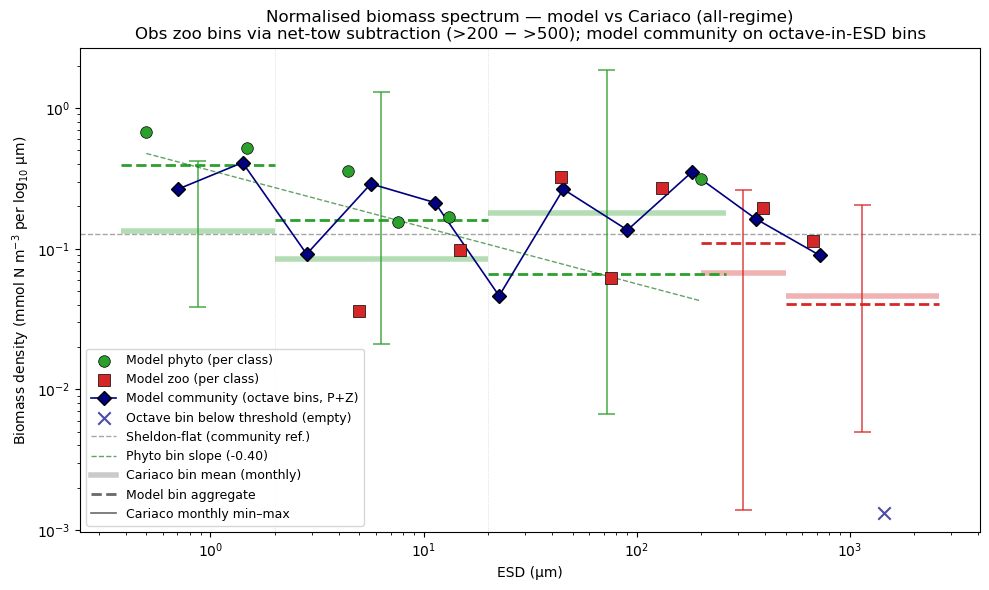

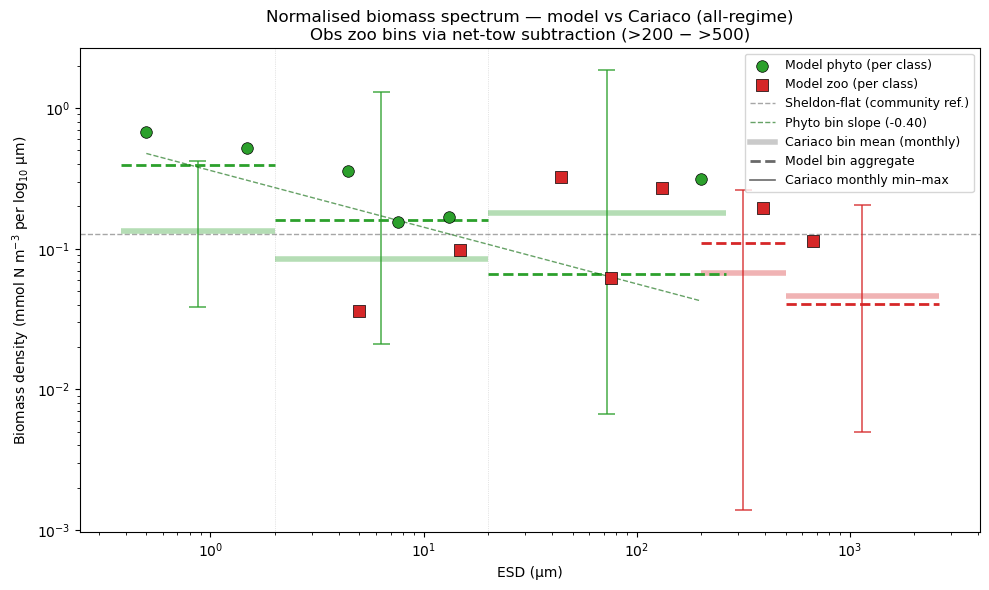

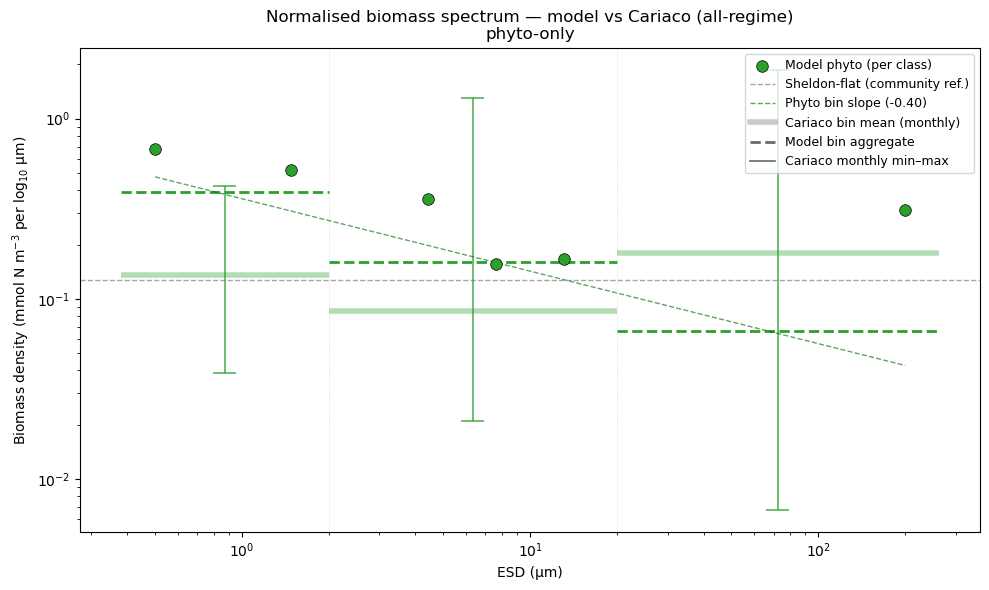

In [13]:
# Default — full plot, P+Z + 5-bin overlay + octave community
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd, regime='all',
)

# Without octave bins
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd,
    regime='all', show_octave=False,
)

# Phyto only, no octave
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd,
    regime='all', show_zoo=False, show_octave=False,
)

In [10]:
n_P_new, n_Z_new = 6, 6
P_new = generate_size_classes(n_P_new, esd_min=0.5, esd_max=200)
Z_new = generate_size_classes(n_Z_new, esd_min=5,   esd_max=2000)

regen = build_cariaco_regenerators(
    compute_K_s, compute_mu_max_maranon,
    compute_I_max, compute_fish_kernel_vdl_joint,
)

new_setup_ivp = make_resized_setup(
    loaded_setup=loaded_setup, model=model,
    phyto_esd=P_new, zoo_esd=Z_new,
    regenerators=regen,
    solver='solve_ivp', time=np.arange(0, 5000, 1),
)

new_setup_stab = make_resized_setup(
    loaded_setup=loaded_setup, model=model,
    phyto_esd=P_new, zoo_esd=Z_new,
    regenerators=regen,
    solver='stability', time=[0, 1],
)

[resize] inherited=46 regenerated=10 skipped_size_dep=10 overrides=0
[resize] inherited=46 regenerated=10 skipped_size_dep=10 overrides=0


In [11]:
# IVP spin-up
with model:
    out_ivp = new_setup_ivp.xsimlab.run()

# Tail-mean of IVP becomes initial condition for stability solver
AVG_WINDOW = 1000
n_avg = float(out_ivp.Nutrient__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
p_avg = (out_ivp.Phytoplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
z_avg = (out_ivp.Zooplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
d_avg = float(out_ivp.Detritus__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)

ss_overrides = {
    'Nutrient__value_init':        n_avg,
    'Phytoplankton__biomass_init': p_avg,
    'Zooplankton__biomass_init':   z_avg,
    'Detritus__value_init':        d_avg,
}

# IMPORTANT: use new_setup_stab (not cariaco's model_setup_stability),
# otherwise the array shapes won't match the resized grid.
with model:
    out_ss = (new_setup_stab
              .xsimlab.update_vars(input_vars=ss_overrides)
              .xsimlab.run())

ss_phyto_new = out_ss.Phytoplankton__biomass.isel(time=-1).values
ss_zoo_new   = out_ss.Zooplankton__biomass.isel(time=-1).values
ss_nut_new   = float(out_ss.Nutrient__value.isel(time=-1).values)

[INFO] Initial state dimension: 14
[INFO] Initial state: [1.63956986e+00 1.69933506e-01 1.22814733e-01 1.12839673e-01
 4.48360051e-02 4.59316814e-70 3.61642848e-11 8.88154666e-03
 2.91611583e-02 1.00114499e-01 6.49442672e-02 5.77400754e-02
 6.92262914e-46 5.13739497e-01]
[INFO] Steady state found with residual norm: 2.47e-17
  Steady state: [1.63956988e+00 1.69933497e-01 1.22814736e-01 1.12839675e-01
 4.48360053e-02 1.13143039e-79 1.83658197e-20 8.88154534e-03
 2.91611567e-02 1.00114498e-01 6.49442672e-02 5.77400754e-02
 1.60289054e-56 5.13739487e-01]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 14 eigenvalues


<Axes: title={'center': 'Normalised biomass spectrum — model vs Cariaco (all-regime)\nObs zoo bins via net-tow subtraction (>200 − >500); model community on octave-in-ESD bins'}, xlabel='ESD (µm)', ylabel='Biomass density (mmol N m$^{-3}$ per log$_{10}$ µm)'>

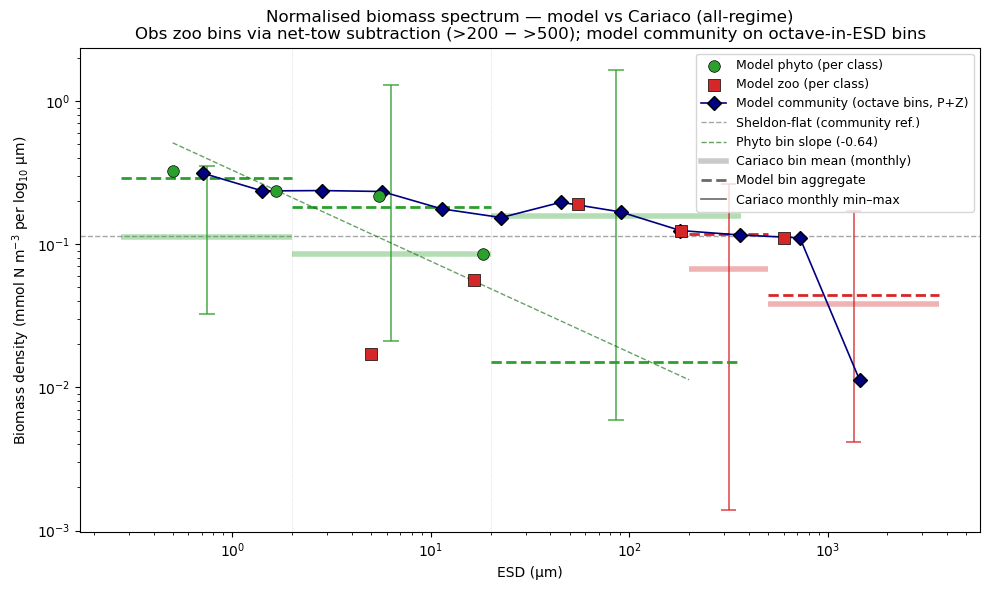

In [12]:
plot_normalised_biomass_spectrum(
    ss_phyto_new, ss_zoo_new, P_new, Z_new, regime='all',
)

In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

from cariaco_ssm_setup import model, model_setup, model_setup_slim, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets

In [2]:
import xarray as xr
loaded_setup = xr.open_dataset('../parameter_scan/best_cell_stability.nc')


from xso.parscans import StabilityAnalysisHook
hook = StabilityAnalysisHook()

with model:
    out = loaded_setup.xsimlab.run(hooks=[hook])

results = hook.get_results()
# now plot from `out` exactly like before

results


ss_phyto = out.Phytoplankton__biomass.isel(time=-1).values
ss_zoo   = out.Zooplankton__biomass.isel(time=-1).values
ss_nut   = float(out.Nutrient__value.isel(time=-1).values)

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[INFO] Initial state dimension: 26
[INFO] Initial state: [1.83352691e+00 1.60011862e-01 6.05213700e-05 1.23187868e-01
 3.83362792e-26 8.46492394e-02 3.62347518e-02 3.96785868e-02
 1.43968986e-13 3.14112594e-54 4.29308458e-51 1.81313137e-14
 7.29897716e-02 8.53953281e-03 1.13686586e-08 2.33246174e-02
 4.81848718e-07 7.70831889e-02 1.46757021e-02 6.37322799e-02
 3.57692353e-06 4.60046055e-02 2.63438222e-02 1.98738377e-04
 1.30556627e-19 5.13293174e-01]
[INFO] Steady state found with residual norm: 2.45e-14
  Steady state: [ 1.83153926e+00  1.60014863e-01  1.64855568e-13  1.23199600e-01
 -3.65114524e-35  8.43462784e-02  3.67934893e-02  3.94917915e-02
 -5.65341929e-21  1.33941511e-63  8.12595782e-60  7.12624838e-23
  7.37316341e-02  8.53993542e-03  6.84770655e-16  2.33278508e-02
 -2.04361297e-15  7.70578848e-02  1.46454702e-02  6.36644862e-02
  2.42916200e-15  4.57155644e-02  2.69044037e-02  1.47319163e-12
  5.514828

<Axes: title={'center': 'Normalised biomass spectrum — model vs Cariaco (all-regime)\nphyto-only'}, xlabel='ESD (µm)', ylabel='Biomass density (mmol N m$^{-3}$ per log$_{10}$ µm)'>

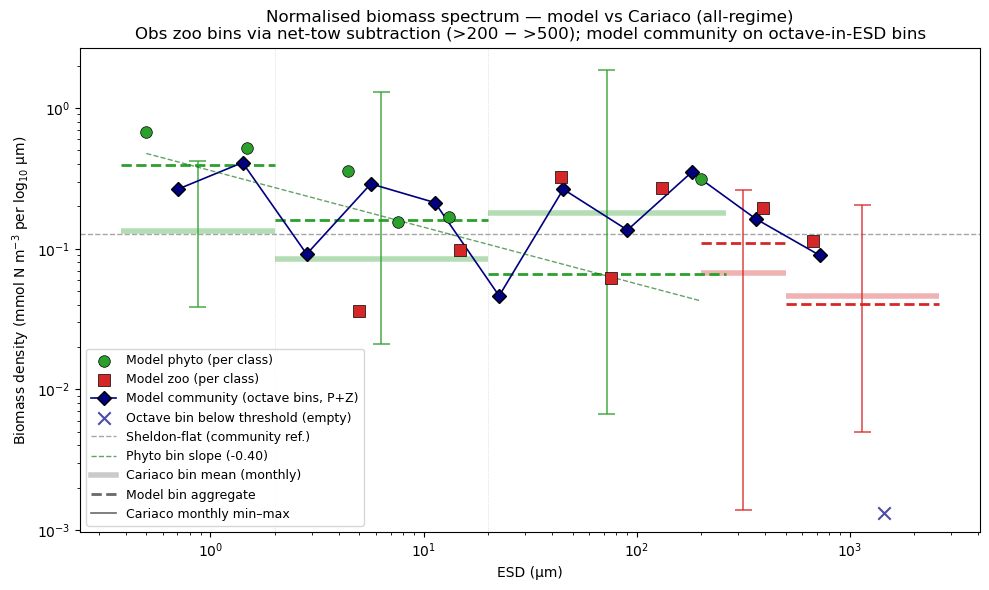

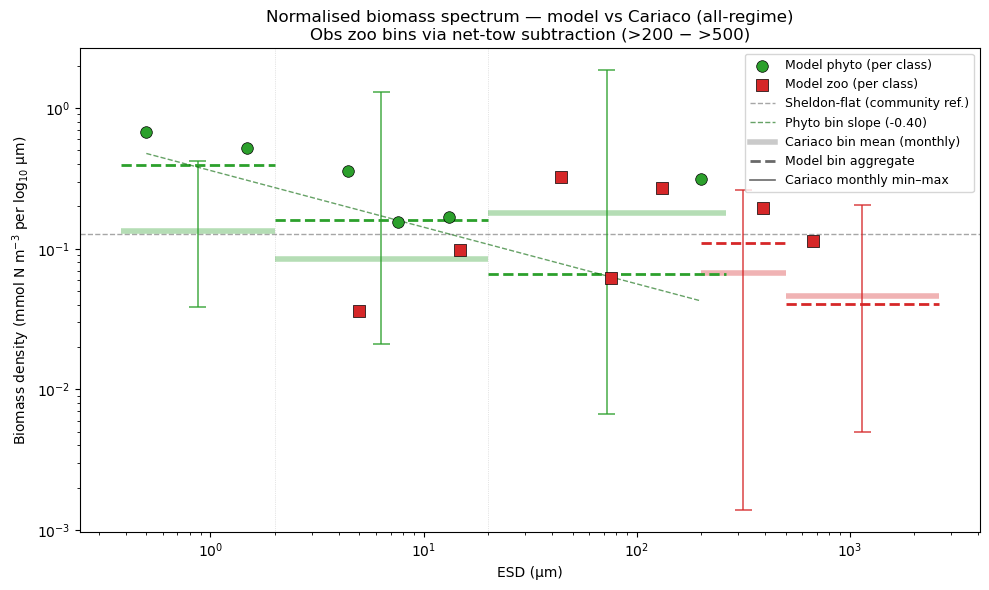

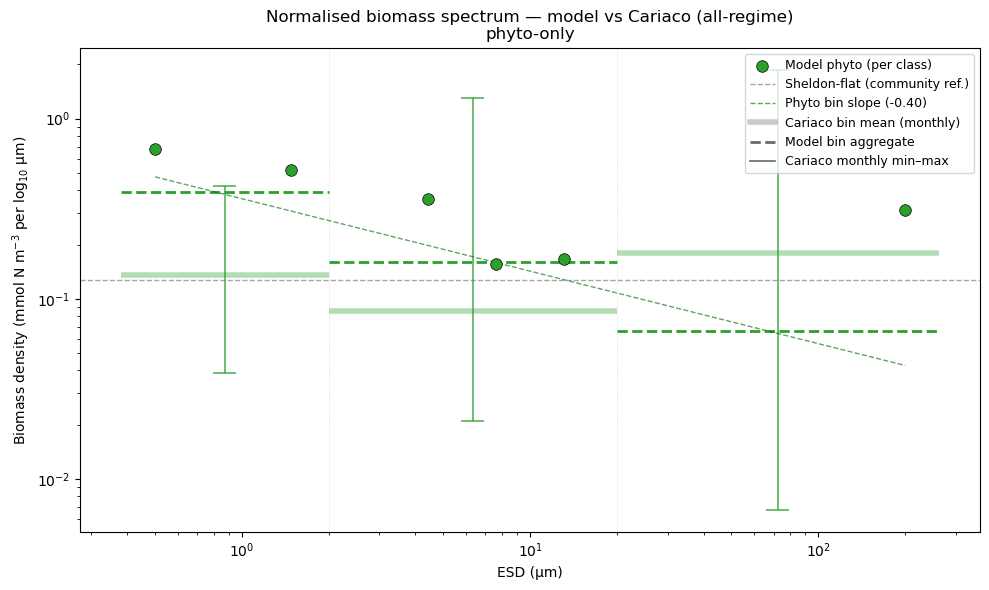

In [3]:
from spectrum_plot import plot_normalised_biomass_spectrum

# Default — full plot, P+Z + 5-bin overlay + octave community
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd, regime='all',
)

# Without octave bins
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd,
    regime='all', show_octave=False,
)

# Phyto only, no octave
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd,
    regime='all', show_zoo=False, show_octave=False,
)

In [4]:
import xarray as xr, numpy as np
from cariaco_ssm_setup import (
    model, generate_size_classes,
    compute_K_s, compute_mu_max_maranon, compute_I_max,
    compute_fish_kernel_vdl_joint,
)
from resize_cariaco_setup import make_resized_setup, build_cariaco_regenerators

loaded = xr.open_dataset('../parameter_scan/best_cell_stability.nc')

n_P_new, n_Z_new = 30, 30
P_new = generate_size_classes(n_P_new, esd_min=0.5, esd_max=200)
Z_new = generate_size_classes(n_Z_new, esd_min=5,   esd_max=2000)

regen = build_cariaco_regenerators(
    compute_K_s, compute_mu_max_maranon,
    compute_I_max, compute_fish_kernel_vdl_joint,
)

new_setup_ivp = make_resized_setup(
    loaded_setup=loaded, model=model,
    phyto_esd=P_new, zoo_esd=Z_new,
    regenerators=regen,
    solver='solve_ivp',
    time=np.arange(0, 5000, 1),
)

new_setup_stab = make_resized_setup(
    loaded_setup=loaded, model=model,
    phyto_esd=P_new, zoo_esd=Z_new,
    regenerators=regen,
    solver='stability', time=[0, 1],
)


with model:
    out_1 = new_setup_ivp.xsimlab.run()


[resize] inherited=46 regenerated=10 skipped_size_dep=10 overrides=0
[resize] inherited=46 regenerated=10 skipped_size_dep=10 overrides=0


In [ ]:
# %% =========================================================================
# STAGE 2: IVP tail mean → STABILITY SOLVER
# =============================================================================
AVG_WINDOW = 1000  # adjust if you want a different tail length

n_avg = float(out_ivp.Nutrient__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
p_avg = (out_ivp.Phytoplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
z_avg = (out_ivp.Zooplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
d_avg = float(out_ivp.Detritus__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)

ss_overrides = {
    'Nutrient__value_init':        n_avg,
    'Phytoplankton__biomass_init': p_avg,
    'Zooplankton__biomass_init':   z_avg,
    'Detritus__value_init':        d_avg,
}

from cariaco_ssm_setup import model_setup_stability

with model:
    out_ss = (model_setup_stability
              .xsimlab.update_vars(input_vars=ss_overrides)
              .xsimlab.run())

ss_phyto = out_ss.Phytoplankton__biomass.isel(time=-1).values
ss_zoo   = out_ss.Zooplankton__biomass.isel(time=-1).values
ss_nut   = float(out_ss.Nutrient__value.isel(time=-1).values)

print(f"\n--- Steady-state values (mmol N m-3) ---")
print(f"  N: {ss_nut:.4f}")
for i, esd in enumerate(phyto_esd):
    print(f"  P[{esd:7.2f} µm]: {ss_phyto[i]:.5f}")
for j, esd in enumerate(zoo_esd):
    print(f"  Z[{esd:7.2f} µm]: {ss_zoo[j]:.5f}")

In [ ]:
from spectrum_plot import plot_normalised_biomass_spectrum

# Default — full plot, P+Z + 5-bin overlay + octave community
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd, regime='all',
)

# Without octave bins
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd,
    regime='all', show_octave=False,
)

# Phyto only, no octave
plot_normalised_biomass_spectrum(
    ss_phyto, ss_zoo, phyto_esd, zoo_esd,
    regime='all', show_zoo=False, show_octave=False,
)

In [4]:
print(list(loaded_setup.data_vars))
print()
for name in list(loaded_setup.data_vars)[:5]:
    print(name, '|', loaded_setup[name].dims, '|', loaded_setup[name].values)
print()
print(list(loaded_setup.coords))

['Phytoplankton__biomass_init', 'Phytoplankton__phyto_esd_index', 'Zooplankton__biomass_init', 'Zooplankton__zoo_esd_index', 'Growth__halfsat', 'Growth__mu_max', 'Grazing__Imax', 'PhytoMortality__rate', 'FishGrazing__kernel_P', 'FishGrazing__kernel_Z', 'Phytoplankton__phyto_esd_label', 'Grazing__phyto_esd', 'FishForcing__forcing_label', 'FishGrazing__fish_forcing', 'Core__solver_type', 'Zooplankton__zoo_esd_label', 'Grazing__zoo_esd', 'Time__time_input', 'Nutrient__value_label', 'Phytoplankton__biomass_label', 'Zooplankton__biomass_label', 'Detritus__value_label', 'Inflow__var', 'Growth__resource', 'Growth__consumer', 'Grazing__resource', 'Grazing__consumer', 'GGE__grazed_phyto', 'GGE__grazed_zoo', 'GGE__assimilated_consumer', 'GGE__egested_detritus', 'GGE__excreted_nutrient', 'PhytoMortality__population', 'PhytoMortality__detritus', 'PhytoMortality__nutrient', 'ZooMortality__population', 'ZooMortality__detritus', 'DetritusRemin__detritus', 'DetritusRemin__nutrient', 'DetritusSink__det

In [7]:
import xsimlab as xs
xs.filter_variables(model, var_type='variable')

NotAProcessClassError: <class 'xsimlab.model.Model'> is not a process-decorated class.

In [2]:
REGIME = 'all'
obs_vec, labels, bin_defs, monthly_df, forcing = load_cariaco_targets(regime=REGIME)

forcing['GGE__gge']                 = 0.17416  # Scan 1
forcing['GGE__f_egest_D']           = 0.55602  # Scan 2
forcing['DetritusRemin__k_remin']   = 0.07590  # Scan 2
forcing['PhytoMortality__f_mort_D'] = 0.47651  # Scan 4
forcing['Inflow__FN'] = 2.90041
forcing['Grazing__KsZ'] = 0.38207


In [3]:

with model:
    out_ivp = model_setup.xsimlab.update_vars(input_vars=forcing).xsimlab.run()
out_ivp['time'] = out_ivp.time.round(9)

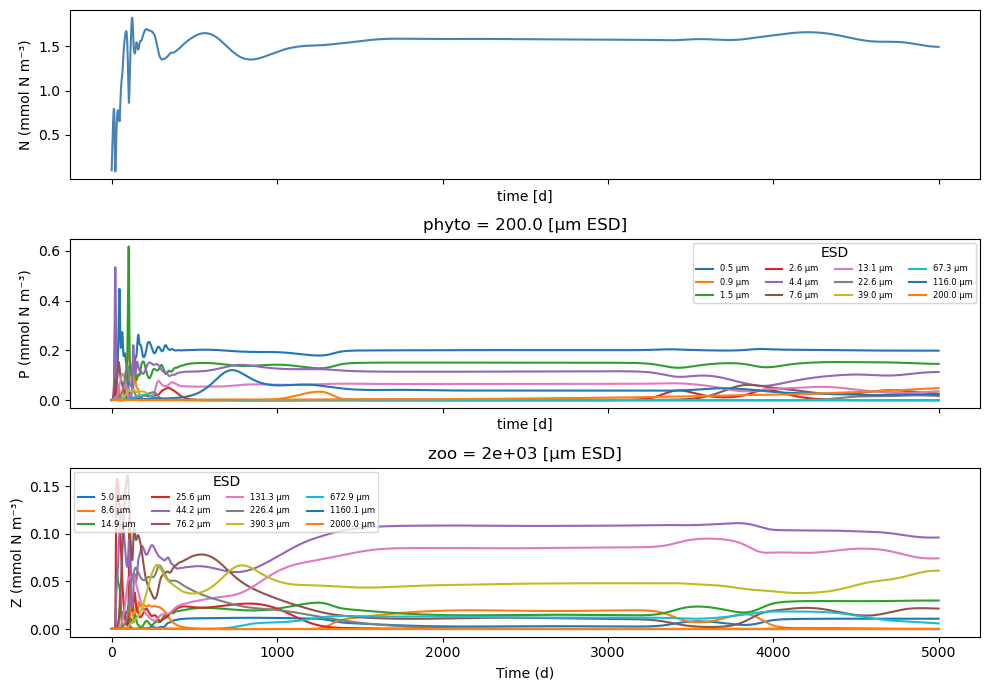

In [4]:
# Quick spin-up diagnostic
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].set_title('IVP Spin-up Diagnostic')
out_ivp['Nutrient__value'].plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('N (mmol N m⁻³)')

P = out_ivp['Phytoplankton__biomass']
for i, esd in enumerate(phyto_esd):
    P.isel(phyto=i).plot(ax=axes[1], label=f'{esd:.1f} µm')
axes[1].set_ylabel('P (mmol N m⁻³)')
axes[1].legend(fontsize=6, ncol=4, title='ESD')

Z = out_ivp['Zooplankton__biomass']
for i, esd in enumerate(zoo_esd):
    Z.isel(zoo=i).plot(ax=axes[2], label=f'{esd:.1f} µm')
axes[2].set_ylabel('Z (mmol N m⁻³)')
axes[2].legend(fontsize=6, ncol=4, title='ESD')
axes[2].set_xlabel('Time (d)')

plt.tight_layout()
plt.show()

In [5]:
# %% =========================================================================
# STAGE 2: IVP tail mean → STABILITY SOLVER
# =============================================================================
AVG_WINDOW = 1000  # adjust if you want a different tail length

n_avg = float(out_ivp.Nutrient__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
p_avg = (out_ivp.Phytoplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
z_avg = (out_ivp.Zooplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
d_avg = float(out_ivp.Detritus__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)

ss_overrides = {
    'Nutrient__value_init':        n_avg,
    'Phytoplankton__biomass_init': p_avg,
    'Zooplankton__biomass_init':   z_avg,
    'Detritus__value_init':        d_avg,
}

from cariaco_ssm_setup import model_setup_stability

with model:
    out_ss = (model_setup_stability
              .xsimlab.update_vars(input_vars=ss_overrides)
              .xsimlab.run())

ss_phyto = out_ss.Phytoplankton__biomass.isel(time=-1).values
ss_zoo   = out_ss.Zooplankton__biomass.isel(time=-1).values
ss_nut   = float(out_ss.Nutrient__value.isel(time=-1).values)

print(f"\n--- Steady-state values (mmol N m-3) ---")
print(f"  N: {ss_nut:.4f}")
for i, esd in enumerate(phyto_esd):
    print(f"  P[{esd:7.2f} µm]: {ss_phyto[i]:.5f}")
for j, esd in enumerate(zoo_esd):
    print(f"  Z[{esd:7.2f} µm]: {ss_zoo[j]:.5f}")

[INFO] Initial state dimension: 26
[INFO] Initial state: [1.59037105e+00 2.00484401e-01 8.74265106e-61 1.49275578e-01
 5.42330368e-03 9.61328959e-02 3.36823063e-02 4.13881770e-02
 1.05761417e-02 2.69521125e-22 2.15565022e-20 2.44638209e-02
 3.33652393e-02 1.07320948e-02 4.66710565e-04 2.93631155e-02
 3.65821877e-04 1.01527249e-01 1.92465168e-02 8.05215805e-02
 8.42533893e-08 4.70260816e-02 1.33211472e-02 6.74820743e-17
 1.27832423e-44 5.89406680e-01]
[INFO] Steady state found with residual norm: 1.24e-15
  Steady state: [ 1.24674978e+00  8.96238933e-29  1.68127908e-88 -1.80518104e-31
 -2.20243948e-32  1.82282797e-29  8.09440219e-31  1.25132467e-29
  9.47192815e-28  2.80642042e-46  1.07548274e-43 -7.16533193e-25
  6.21755193e+00  1.20738878e-11  2.41460258e-13 -9.23559840e-12
 -2.54599889e-13  2.92839409e-12  4.15874431e-13  2.96871590e-14
  4.09369600e-16  1.12858797e-14  6.97659598e-21  5.05545516e-22
  1.23099099e-50  4.71866914e-01]
[INFO] Computing Jacobian numerically...
[INFO] Su

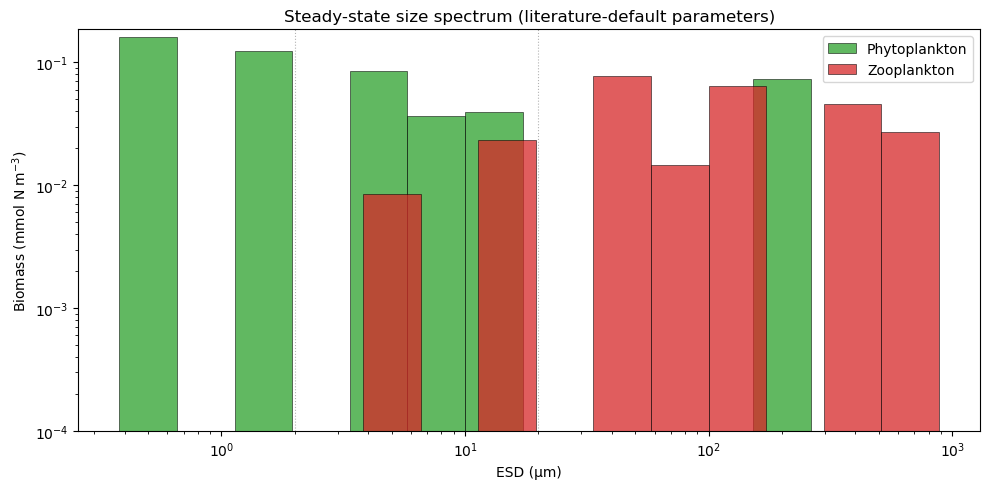

In [11]:
# %% =========================================================================
# STAGE 3: Plot steady-state size spectrum
# =============================================================================
from parscan_utils import get_log_bin_edges

# Floor numerical-noise values; biologically meaningful biomass at
# Cariaco scales is well above this.
THRESHOLD = 1e-10  # mmol N m^-3
ss_phyto_clean = np.where(ss_phyto < THRESHOLD, np.nan, ss_phyto)
ss_zoo_clean   = np.where(ss_zoo   < THRESHOLD, np.nan, ss_zoo)

p_edges = get_log_bin_edges(np.asarray(phyto_esd))
z_edges = get_log_bin_edges(np.asarray(zoo_esd))

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(p_edges[:-1], ss_phyto_clean, width=np.diff(p_edges), align='edge',
       color='tab:green', edgecolor='black', linewidth=0.5,
       alpha=0.75, label='Phytoplankton')
ax.bar(z_edges[:-1], ss_zoo_clean, width=np.diff(z_edges), align='edge',
       color='tab:red', edgecolor='black', linewidth=0.5,
       alpha=0.75, label='Zooplankton')

# Pico / Nano / Micro guides
for x_guide in (2.0, 20.0):
    ax.axvline(x_guide, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-4, None)  # clip below biologically meaningful biomass
ax.set_xlabel('ESD (µm)')
ax.set_ylabel('Biomass (mmol N m$^{-3}$)')
ax.set_title('Steady-state size spectrum (literature-default parameters)')
ax.legend()
plt.tight_layout()
plt.show()

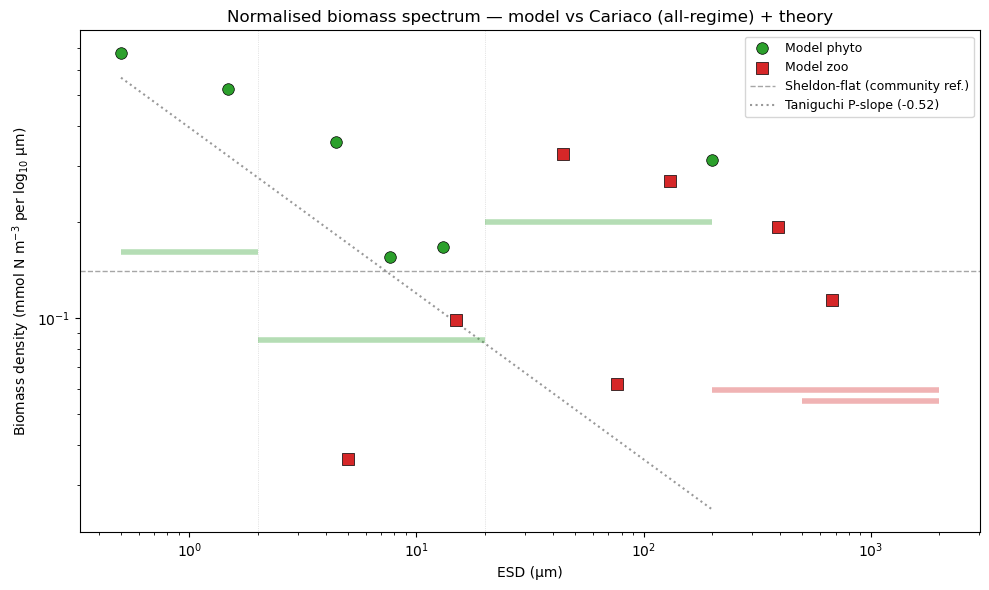

In [12]:
# %% =========================================================================
# STAGE 3 (replacement): Normalised biomass spectrum (community) vs theory + obs
# =============================================================================
from cariaco_obs import load_cariaco_targets
from parscan_utils import get_log_bin_edges

# --- Threshold extinct-class noise ---
THRESHOLD = 1e-7  # mmol N m^-3
ss_phyto_clean = np.where(ss_phyto < THRESHOLD, np.nan, ss_phyto)
ss_zoo_clean   = np.where(ss_zoo   < THRESHOLD, np.nan, ss_zoo)

# --- Log-bin geometry; same ratio for both grids → constant Δlog10 ---
p_edges = get_log_bin_edges(np.asarray(phyto_esd))
z_edges = get_log_bin_edges(np.asarray(zoo_esd))
p_dlog  = np.diff(np.log10(p_edges))
z_dlog  = np.diff(np.log10(z_edges))

# Normalised biomass spectrum (Sheldon-style: B per log size interval)
phyto_nbs = ss_phyto_clean / p_dlog
zoo_nbs   = ss_zoo_clean   / z_dlog

# --- Cariaco observations: integrated bins → bin densities ---
obs_vec, labels, bin_defs, _, _ = load_cariaco_targets(regime='all')

# Caps for semi-infinite obs bins
PHYTO_UPPER = phyto_esd[-1]   # 200 µm
ZOO_UPPER   = zoo_esd[-1]     # 2000 µm
PHYTO_LOWER = phyto_esd[0]    # 0.5 µm — clip Pico's nominal 0.0 µm bound
ZOO_LOWER   = zoo_esd[0]      # 5 µm

obs_segments = []
for k, b in enumerate(bin_defs):
    if b['type'] not in ('phyto', 'zoo'):
        continue
    lo_clip = PHYTO_LOWER if b['type'] == 'phyto' else ZOO_LOWER
    up_clip = PHYTO_UPPER if b['type'] == 'phyto' else ZOO_UPPER
    smin = max(b['size_min'], lo_clip)
    smax = up_clip if np.isinf(b['size_max']) else b['size_max']
    dlog = np.log10(smax) - np.log10(smin)
    obs_segments.append({
        'size_min': smin, 'size_max': smax,
        'density':  obs_vec[k] / dlog,
        'type':     b['type'], 'label': b['label'],
    })

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Model points
ax.scatter(phyto_esd, phyto_nbs, marker='o', s=70,
           color='tab:green', edgecolor='black', linewidth=0.5,
           zorder=5, label='Model phyto')
ax.scatter(zoo_esd, zoo_nbs, marker='s', s=70,
           color='tab:red', edgecolor='black', linewidth=0.5,
           zorder=5, label='Model zoo')

# Observation segments (horizontal bars at bin density)
for seg in obs_segments:
    c = 'tab:green' if seg['type'] == 'phyto' else 'tab:red'
    ax.hlines(seg['density'], seg['size_min'], seg['size_max'],
              colors=c, linewidth=4, alpha=0.35, zorder=3)

# --- Reference slopes, anchored at Cariaco phyto geometric centroid ---
phyto_obs = [s for s in obs_segments if s['type'] == 'phyto']
y_anchor  = np.exp(np.mean(np.log([s['density']        for s in phyto_obs])))
x_anchor  = np.exp(np.mean(np.log([np.sqrt(s['size_min']*s['size_max'])
                                   for s in phyto_obs])))

# Sheldon-flat reference (community structural; slope = 0)
ax.axhline(y_anchor, color='gray', linestyle='--', linewidth=1,
           alpha=0.7, label='Sheldon-flat (community ref.)')

# Taniguchi prediction over the phyto ESD range (slope = -0.52 for MS3)
slope_tani = -0.52
x_tani = np.array([phyto_esd[0], phyto_esd[-1]])
y_tani = y_anchor * (x_tani / x_anchor) ** slope_tani
ax.plot(x_tani, y_tani, color='gray', linestyle=':', linewidth=1.5,
        alpha=0.8, label=f'Taniguchi P-slope ({slope_tani:+.2f})')

# Pico / Nano / Micro guides
for x_guide in (2.0, 20.0):
    ax.axvline(x_guide, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('ESD (µm)')
ax.set_ylabel('Biomass density (mmol N m$^{-3}$ per log$_{10}$ µm)')
ax.set_title('Normalised biomass spectrum — model vs Cariaco (all-regime) + theory')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

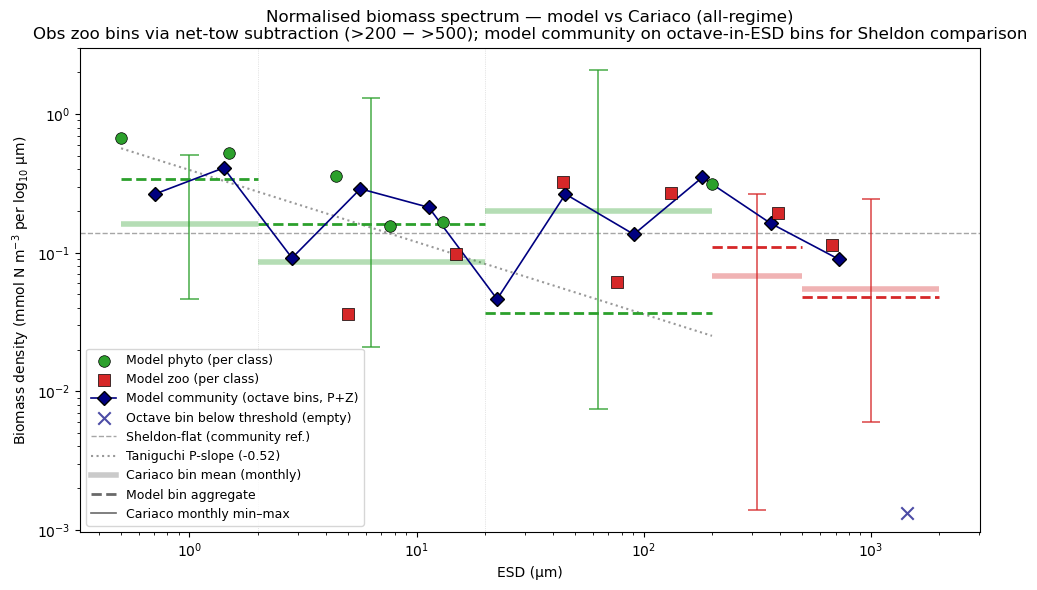

In [21]:
# %% =========================================================================
# STAGE 3 (replacement): Normalised biomass spectrum — model vs Cariaco (all)
#   per-class points + 5-bin overlay (non-overlapping zoo via net-tow subtraction
#   on obs side only) + octave-binned model community for Sheldon comparison
# =============================================================================
from cariaco_obs import load_cariaco_targets
from parscan_utils import get_log_bin_edges, get_fraction_in_range
from matplotlib.lines import Line2D

# --- Threshold extinct-class noise (visual-only on per-class scatter) ---
THRESHOLD = 1e-7  # mmol N m^-3
ss_phyto_clean = np.where(ss_phyto < THRESHOLD, np.nan, ss_phyto)
ss_zoo_clean   = np.where(ss_zoo   < THRESHOLD, np.nan, ss_zoo)

# --- Log-bin geometry; same ratio for both grids → constant Δlog10 ---
p_edges = get_log_bin_edges(np.asarray(phyto_esd))
z_edges = get_log_bin_edges(np.asarray(zoo_esd))
p_dlog  = np.diff(np.log10(p_edges))
z_dlog  = np.diff(np.log10(z_edges))

# Per-class normalised biomass spectrum
phyto_nbs = ss_phyto_clean / p_dlog
zoo_nbs   = ss_zoo_clean   / z_dlog

# --- Cariaco observations + monthly_df (kept for spread) ---
obs_vec, labels, bin_defs, monthly_df, _ = load_cariaco_targets(regime='all')

# Caps
PHYTO_UPPER = phyto_esd[-1]   # 200 µm
ZOO_UPPER   = zoo_esd[-1]     # 2000 µm
PHYTO_LOWER = phyto_esd[0]    # 0.5 µm
ZOO_LOWER   = zoo_esd[0]      # 5 µm

ss_phyto_arr = np.asarray(ss_phyto)
ss_zoo_arr   = np.asarray(ss_zoo)

# --- Helpers: model integration + obs lookup ---
def _phyto_in(smin, smax):
    """Sum of phyto class biomass within (smin, smax], fraction-weighted."""
    return sum(ss_phyto_arr[i] * get_fraction_in_range(
        p_edges[i], p_edges[i+1], smin, smax)
        for i in range(len(phyto_esd)))

def _zoo_in(smin, smax):
    """Sum of zoo class biomass within (smin, smax], fraction-weighted."""
    return sum(ss_zoo_arr[i] * get_fraction_in_range(
        z_edges[i], z_edges[i+1], smin, smax)
        for i in range(len(zoo_esd)))

def _obs_by_label(lbl):
    k = next(i for i, b in enumerate(bin_defs) if b['label'] == lbl)
    return obs_vec[k]

def _monthly_by_label(lbl):
    k = next(i for i, b in enumerate(bin_defs) if b['label'] == lbl)
    return monthly_df[bin_defs[k]['column']]

# --- Non-overlapping plot bins ---
# Obs zoo via net-tow subtraction (>200 − >500). Model side does NOT subtract:
# direct integration on (200, 500] uses model classes with no measurement nesting.
zoo_200_500_monthly = (
    _monthly_by_label('Zoo >200 µm') - _monthly_by_label('Zoo >500 µm')
).clip(lower=0.0)  # net-tow noise floor

plot_bins = [
    {'label': 'Pico (0.5–2 µm)',  'type': 'phyto',
     'smin': PHYTO_LOWER, 'smax': 2.0,
     'obs':     _obs_by_label('Pico (<2 µm)'),
     'monthly': _monthly_by_label('Pico (<2 µm)'),
     'model':   _phyto_in(PHYTO_LOWER, 2.0)},

    {'label': 'Nano (2–20 µm)',   'type': 'phyto',
     'smin': 2.0, 'smax': 20.0,
     'obs':     _obs_by_label('Nano (2-20 µm)'),
     'monthly': _monthly_by_label('Nano (2-20 µm)'),
     'model':   _phyto_in(2.0, 20.0)},

    {'label': 'Micro (20–200 µm)', 'type': 'phyto',
     'smin': 20.0, 'smax': PHYTO_UPPER,
     'obs':     _obs_by_label('Micro (>20 µm)'),
     'monthly': _monthly_by_label('Micro (>20 µm)'),
     'model':   _phyto_in(20.0, PHYTO_UPPER)},

    {'label': 'Zoo (200–500 µm]',  'type': 'zoo',
     'smin': 200.0, 'smax': 500.0,
    'obs': max(zoo_200_500_monthly.dropna().mean(), 0.0),
     'monthly': zoo_200_500_monthly,
     'model':   _zoo_in(200.0, 500.0)},

    {'label': 'Zoo (500–2000 µm]', 'type': 'zoo',
     'smin': 500.0, 'smax': ZOO_UPPER,
     'obs':     _obs_by_label('Zoo >500 µm'),
     'monthly': _monthly_by_label('Zoo >500 µm'),
     'model':   _zoo_in(500.0, ZOO_UPPER)},
]

# --- Per-bin segments + monthly min/max ---
obs_segments, model_segments, obs_whiskers = [], [], []
for b in plot_bins:
    smin, smax = b['smin'], b['smax']
    dlog = np.log10(smax) - np.log10(smin)
    geo  = np.sqrt(smin * smax)

    obs_segments.append({
        'size_min': smin, 'size_max': smax,
        'density':  b['obs'] / dlog,
        'type':     b['type'], 'label': b['label'],
    })
    model_segments.append({
        'size_min': smin, 'size_max': smax,
        'density':  b['model'] / dlog,
        'type':     b['type'], 'label': b['label'],
    })

    monthly_vals = b['monthly'].dropna()
    monthly_vals = monthly_vals[monthly_vals > 0].to_numpy()
    if monthly_vals.size:
        obs_whiskers.append({
            'x':     geo,
            'y_min': monthly_vals.min() / dlog,
            'y_max': monthly_vals.max() / dlog,
            'type':  b['type'],
        })

# --- Octave-binned model community (P+Z) for Sheldon-flat comparison ---
# Octaves-in-ESD (factor 2) over 0.5–2048 µm. Closest log-spaced grid to the
# Sheldon-style biomass-per-octave convention when expressed on the ESD axis.
# Each octave bin catches ≈ 2 model classes (model grid factor ≈ 1.74).
octave_edges = np.array([0.5 * 2**i for i in range(13)])  # 0.5 → 2048 µm
octave_smin  = octave_edges[:-1]
octave_smax  = octave_edges[1:]
octave_geo   = np.sqrt(octave_smin * octave_smax)
octave_dlog  = np.log10(octave_smax) - np.log10(octave_smin)

octave_phyto = np.array([_phyto_in(s, e) for s, e in zip(octave_smin, octave_smax)])
octave_zoo   = np.array([_zoo_in(s, e)   for s, e in zip(octave_smin, octave_smax)])
octave_comm  = octave_phyto + octave_zoo

# Threshold near-empty bins out — below this is numerical noise, not biomass
OCTAVE_THRESHOLD = 1e-6  # mmol N m^-3 per bin (≈ 10× per-class noise floor)
octave_density = np.where(octave_comm > OCTAVE_THRESHOLD,
                          octave_comm / octave_dlog, np.nan)
masked_octave_idx = np.where(np.isnan(octave_density))[0]
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Per-class model points (headline visual)
ax.scatter(phyto_esd, phyto_nbs, marker='o', s=70,
           color='tab:green', edgecolor='black', linewidth=0.5,
           zorder=5, label='Model phyto (per class)')
ax.scatter(zoo_esd, zoo_nbs, marker='s', s=70,
           color='tab:red', edgecolor='black', linewidth=0.5,
           zorder=5, label='Model zoo (per class)')

# Cariaco bin central tendency (linear monthly mean)
for seg in obs_segments:
    c = 'tab:green' if seg['type'] == 'phyto' else 'tab:red'
    ax.hlines(seg['density'], seg['size_min'], seg['size_max'],
              colors=c, linewidth=4, alpha=0.35, zorder=3)

# Cariaco monthly min–max whiskers at each bin's geometric centre
CAP_LOG = 0.04
for w in obs_whiskers:
    c = 'tab:green' if w['type'] == 'phyto' else 'tab:red'
    ax.vlines(w['x'], w['y_min'], w['y_max'],
              colors=c, linewidth=1.2, alpha=0.8, zorder=3.5)
    x_lo, x_hi = w['x'] * 10**(-CAP_LOG), w['x'] * 10**(+CAP_LOG)
    ax.hlines([w['y_min'], w['y_max']], x_lo, x_hi,
              colors=c, linewidth=1.2, alpha=0.8, zorder=3.5)

# Bin-aggregated model overlay (dashed, same colour, full opacity)
for seg in model_segments:
    c = 'tab:green' if seg['type'] == 'phyto' else 'tab:red'
    ax.hlines(seg['density'], seg['size_min'], seg['size_max'],
              colors=c, linestyles='dashed', linewidth=2.0,
              alpha=1.0, zorder=4)

# Octave-binned model community spectrum (P+Z, model only)
ax.plot(octave_geo, octave_density,
        marker='D', markersize=7, linestyle='-', linewidth=1.2,
        color='navy', markerfacecolor='navy', markeredgecolor='black',
        zorder=4.5, label='Model community (octave bins, P+Z)')
# Mark octave bins below the biomass threshold (empty / numerical noise)
if len(masked_octave_idx) > 0:
    ax.scatter(octave_geo[masked_octave_idx],
               np.full(len(masked_octave_idx), 0.04),
               transform=ax.get_xaxis_transform(),
               marker='x', s=80, color='navy', alpha=0.7, zorder=4.5,
               label='Octave bin below threshold (empty)')

# --- Reference slopes, anchored at Cariaco phyto geometric centroid ---
phyto_obs = [s for s in obs_segments if s['type'] == 'phyto']
y_anchor  = np.exp(np.mean(np.log([s['density']        for s in phyto_obs])))
x_anchor  = np.exp(np.mean(np.log([np.sqrt(s['size_min']*s['size_max'])
                                   for s in phyto_obs])))

ax.axhline(y_anchor, color='gray', linestyle='--', linewidth=1,
           alpha=0.7, label='Sheldon-flat (community ref.)')

slope_tani = -0.52
x_tani = np.array([phyto_esd[0], phyto_esd[-1]])
y_tani = y_anchor * (x_tani / x_anchor) ** slope_tani
ax.plot(x_tani, y_tani, color='gray', linestyle=':', linewidth=1.5,
        alpha=0.8, label=f'Taniguchi P-slope ({slope_tani:+.2f})')

# Pico / Nano / Micro guides
for x_guide in (2.0, 20.0):
    ax.axvline(x_guide, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)

# --- Legend: combine auto handles + manual handles for looped overlays ---
extra_handles = [
    Line2D([0], [0], color='dimgray', linewidth=4, alpha=0.35,
           label='Cariaco bin mean (monthly)'),
    Line2D([0], [0], color='dimgray', linestyle='dashed', linewidth=2,
           label='Model bin aggregate'),
    Line2D([0], [0], color='dimgray', linewidth=1.2,
           label='Cariaco monthly min–max'),
]
auto_h, auto_l = ax.get_legend_handles_labels()
ax.legend(auto_h + extra_handles,
          auto_l + [h.get_label() for h in extra_handles],
          loc='best', fontsize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('ESD (µm)')
ax.set_ylabel('Biomass density (mmol N m$^{-3}$ per log$_{10}$ µm)')
ax.set_title('Normalised biomass spectrum — model vs Cariaco (all-regime)\n'
             'Obs zoo bins via net-tow subtraction (>200 − >500); '
             'model community on octave-in-ESD bins for Sheldon comparison')
plt.tight_layout()
plt.show()

In [22]:
np.polyfit(np.log10(phyto_esd[surv]), np.log10(phyto_nbs[surv]), 1)[0]

NameError: name 'surv' is not defined

In [23]:
import numpy as np

THRESHOLD = 1e-7  # match spectrum_plot's extinct_threshold

phyto_arr = np.asarray(ss_phyto)
esd_arr   = np.asarray(phyto_esd)
mask      = phyto_arr >= THRESHOLD

# In /Δlog (your current plot's normalization), per-class slope == raw B_i slope
# because Δlog is constant for log-spaced grids
slope_log = np.polyfit(np.log10(esd_arr[mask]),
                       np.log10(phyto_arr[mask]), 1)[0]

print(f"per-class phyto slope, /Δlog₁₀ (your plot):  {slope_log:+.3f}")
print(f"per-class phyto slope, /Δs (Taniguchi conv): {slope_log - 1:+.3f}")

per-class phyto slope, /Δlog₁₀ (your plot):  -0.158
per-class phyto slope, /Δs (Taniguchi conv): -1.158


In [24]:
import numpy as np
from cariaco_obs import load_cariaco_targets
from parscan_utils import aggregate_model_to_targets

obs_vec, _, bin_defs, _, _ = load_cariaco_targets(regime='all')
phyto_bins  = [b for b in bin_defs if b['type'] == 'phyto']
model_state = {'phyto': np.asarray(ss_phyto), 'zoo': np.asarray(ss_zoo)}
model_vec   = aggregate_model_to_targets(
    model_state, phyto_esd, zoo_esd, phyto_bins
)

PHYTO_LOWER, PHYTO_UPPER = phyto_esd[0], phyto_esd[-1]
centers, densities = [], []
for k, b in enumerate(phyto_bins):
    smin = max(b['size_min'], PHYTO_LOWER)
    smax = PHYTO_UPPER if np.isinf(b['size_max']) else b['size_max']
    dlog = np.log10(smax) - np.log10(smin)
    centers.append(np.sqrt(smin * smax))
    densities.append(model_vec[k] / dlog)

slope = np.polyfit(np.log10(centers), np.log10(densities), 1)[0]
print(f"phyto BIN density slope, /Δlog₁₀: {slope:+.3f}")
print(f"phyto BIN density slope, /Δs:     {slope - 1:+.3f}")

phyto BIN density slope, /Δlog₁₀: -0.442
phyto BIN density slope, /Δs:     -1.442
